<a href="https://colab.research.google.com/github/fabrizzioarteagac-dev/reproduccion-slstm-trafico-5g/blob/main/ArteagaCF_SLSTM_Milan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import kagglehub
import os

tf.random.set_seed(42)
np.random.seed(42)

path = kagglehub.dataset_download("marcodena/mobile-phone-activity")
archivos = sorted([f for f in os.listdir(path) if f.startswith("sms-call-internet")])
print("Total de archivos diarios:", len(archivos))
print(archivos[:5])

Using Colab cache for faster access to the 'mobile-phone-activity' dataset.
Total de archivos diarios: 7
['sms-call-internet-mi-2013-11-01.csv', 'sms-call-internet-mi-2013-11-02.csv', 'sms-call-internet-mi-2013-11-03.csv', 'sms-call-internet-mi-2013-11-04.csv', 'sms-call-internet-mi-2013-11-05.csv']


In [5]:
import kagglehub, os

path2 = kagglehub.dataset_download("freckled/telecom")
archivos2 = sorted([f for f in os.listdir(path2) if "sms-call-internet" in f or f.endswith(".csv")])
print("Total de archivos en 'freckled/telecom':", len(archivos2))
print(archivos2[:10])

Resuming download from 1037041664 bytes (4343690985 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/freckled/telecom/3.archive (1037041664/5380732649) bytes left.


100%|██████████| 5.01G/5.01G [00:35<00:00, 121MB/s]

Extracting files...


Total de archivos en 'freckled/telecom': 2
['data1.csv', 'data2.csv']


In [6]:
import pandas as pd

for f in ["data1.csv", "data2.csv"]:
    print(f"--- {f} ---")
    muestra = pd.read_csv(os.path.join(path2, f), nrows=5)
    print(muestra.shape, "(muestra de 5 filas, no el archivo completo)")
    print(muestra.columns.tolist())
    print(muestra)
    print()

--- data1.csv ---
(5, 8) (muestra de 5 filas, no el archivo completo)
['GridID', 'TimeInterval', 'countrycode', 'smsin', 'smsout', 'callin', 'callout', 'internet']
   GridID   TimeInterval  countrycode     smsin    smsout    callin   callout  \
0       1  1383260400000            0  0.081363       NaN       NaN       NaN   
1       1  1383260400000           39  0.141864  0.156787  0.160938  0.052275   
2       1  1383261000000            0  0.136588       NaN       NaN  0.027300   
3       1  1383261000000           33       NaN       NaN       NaN       NaN   
4       1  1383261000000           39  0.278452  0.119926  0.188777  0.133637   

    internet  
0        NaN  
1  11.028366  
2        NaN  
3   0.026137  
4  11.100963  

--- data2.csv ---
(5, 8) (muestra de 5 filas, no el archivo completo)
['GridID', 'TimeInterval', 'countrycode', 'smsin', 'smsout', 'callin', 'callout', 'internet']
   GridID   TimeInterval  countrycode     smsin    smsout    callin   callout  \
0       1  13

In [7]:
def agregar_por_chunks(filepath, chunksize=5_000_000):
    acumulado = {}
    for i, chunk in enumerate(pd.read_csv(filepath, usecols=["TimeInterval", "internet"],
                                            dtype={"internet": "float32"}, chunksize=chunksize)):
        parcial = chunk.groupby("TimeInterval")["internet"].sum()
        for t, v in parcial.items():
            acumulado[t] = acumulado.get(t, 0.0) + v
        print(f"    chunk {i+1} procesado ({chunksize*(i+1):,} filas leídas aprox.)")
    return acumulado

acumulado_total = {}
for f in ["data1.csv", "data2.csv"]:
    print(f"--- procesando {f} ---")
    parcial = agregar_por_chunks(os.path.join(path2, f))
    for t, v in parcial.items():
        acumulado_total[t] = acumulado_total.get(t, 0.0) + v

milan = pd.DataFrame(list(acumulado_total.items()), columns=["TimeInterval", "internet"])
milan["datetime"] = pd.to_datetime(milan["TimeInterval"], unit="ms")
milan = milan.sort_values("datetime").reset_index(drop=True)[["datetime", "internet"]]

print("\nSerie final:", milan.shape)
print("Rango:", milan["datetime"].min(), "a", milan["datetime"].max())
milan.to_csv("/content/milan_traffic_10min.csv", index=False)
milan.head(10)

--- procesando data1.csv ---
    chunk 1 procesado (5,000,000 filas leídas aprox.)
    chunk 2 procesado (10,000,000 filas leídas aprox.)
    chunk 3 procesado (15,000,000 filas leídas aprox.)
    chunk 4 procesado (20,000,000 filas leídas aprox.)
    chunk 5 procesado (25,000,000 filas leídas aprox.)
    chunk 6 procesado (30,000,000 filas leídas aprox.)
    chunk 7 procesado (35,000,000 filas leídas aprox.)
    chunk 8 procesado (40,000,000 filas leídas aprox.)
    chunk 9 procesado (45,000,000 filas leídas aprox.)
    chunk 10 procesado (50,000,000 filas leídas aprox.)
    chunk 11 procesado (55,000,000 filas leídas aprox.)
    chunk 12 procesado (60,000,000 filas leídas aprox.)
    chunk 13 procesado (65,000,000 filas leídas aprox.)
    chunk 14 procesado (70,000,000 filas leídas aprox.)
    chunk 15 procesado (75,000,000 filas leídas aprox.)
    chunk 16 procesado (80,000,000 filas leídas aprox.)
    chunk 17 procesado (85,000,000 filas leídas aprox.)
    chunk 18 procesado (90,00

,datetime,internet
0,2013-10-31 23:00:00,642388.31250
1,2013-10-31 23:10:00,630005.12500
2,2013-10-31 23:20:00,619933.18750
3,2013-10-31 23:30:00,590963.06250
4,2013-10-31 23:40:00,577130.06250
5,2013-10-31 23:50:00,563293.43750
6,2013-11-01 00:00:00,543777.68750
7,2013-11-01 00:10:00,532706.00000
8,2013-11-01 00:20:00,514802.03125
9,2013-11-01 00:30:00,511871.59375


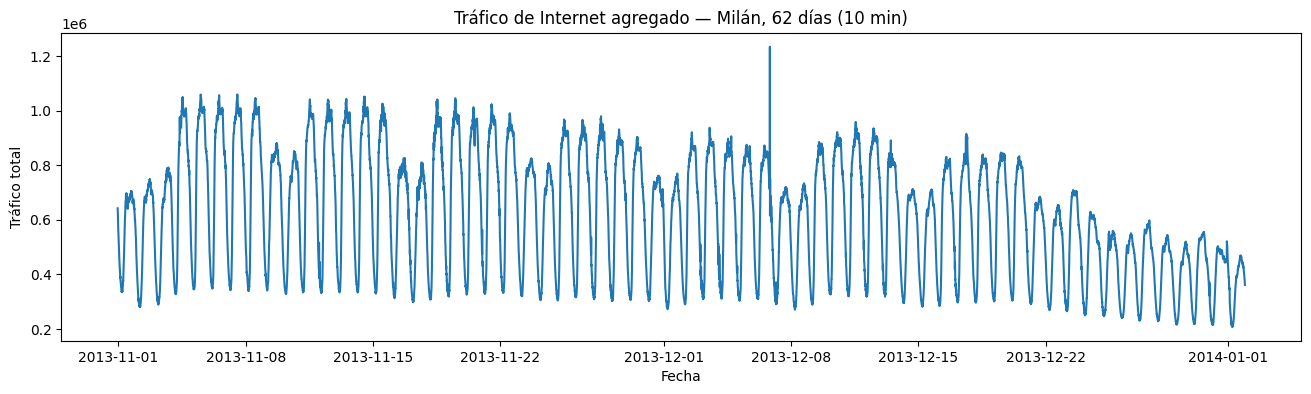

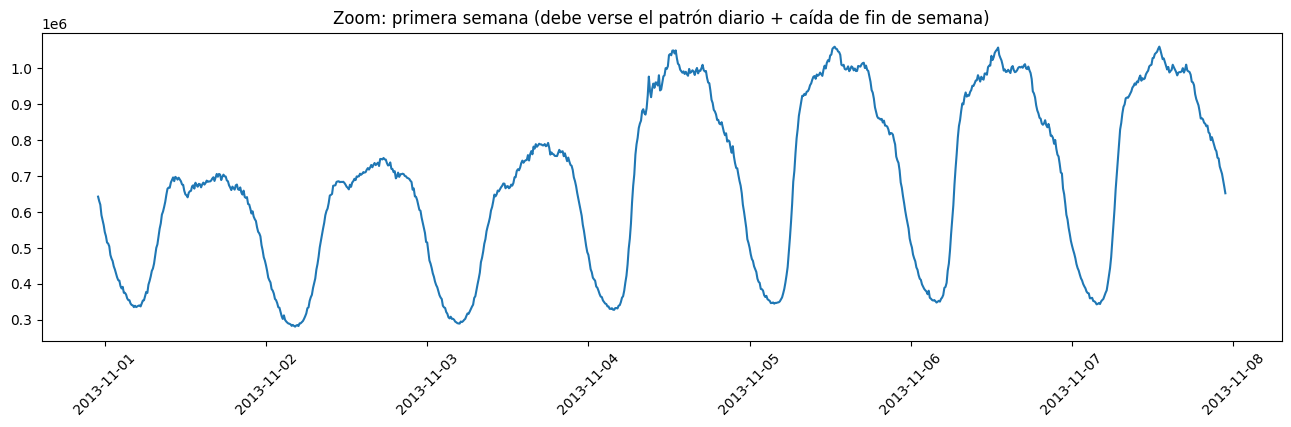

In [8]:
plt.figure(figsize=(16, 4))
plt.plot(milan["datetime"], milan["internet"])
plt.title("Tráfico de Internet agregado — Milán, 62 días (10 min)")
plt.xlabel("Fecha"); plt.ylabel("Tráfico total")
plt.show()

plt.figure(figsize=(16, 4))
sample = milan.iloc[:144*7]  # primera semana
plt.plot(sample["datetime"], sample["internet"])
plt.title("Zoom: primera semana (debe verse el patrón diario + caída de fin de semana)")
plt.xticks(rotation=45)
plt.show()

Puntos antes de diferenciar: 8928 | despues: 8784


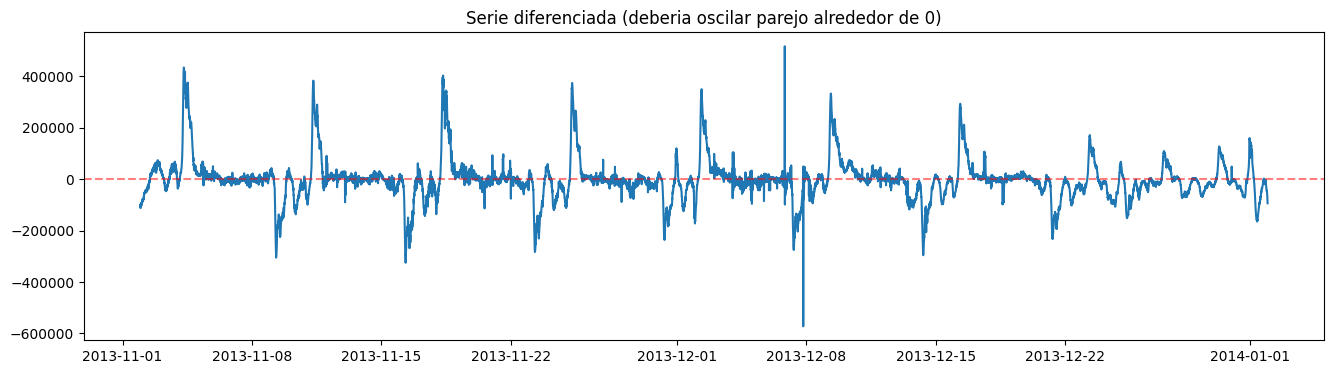

In [9]:
milan["hour_frac"] = milan["datetime"].dt.hour + milan["datetime"].dt.minute / 60
milan["dow"] = milan["datetime"].dt.dayofweek

milan["hour_sin"] = np.sin(2 * np.pi * milan["hour_frac"] / 24)
milan["hour_cos"] = np.cos(2 * np.pi * milan["hour_frac"] / 24)
milan["dow_sin"] = np.sin(2 * np.pi * milan["dow"] / 7)
milan["dow_cos"] = np.cos(2 * np.pi * milan["dow"] / 7)

SEASON = 144  # 24h a intervalos de 10 min (equivalente al periodo de 24h del paper original)
milan["internet_diff"] = milan["internet"].diff(SEASON)
data = milan.dropna(subset=["internet_diff"]).reset_index(drop=True)
print(f"Puntos antes de diferenciar: {len(milan)} | despues: {len(data)}")

plt.figure(figsize=(16, 4))
plt.plot(data["datetime"], data["internet_diff"])
plt.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.title("Serie diferenciada (deberia oscilar parejo alrededor de 0)")
plt.show()

In [10]:
FEATURES = ["internet_diff", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]
TARGET_COL = "internet_diff"
K = len(FEATURES)

def split_scale(data, features_model, train_frac=0.8):
    train_size = int(len(data) * train_frac)
    train_df = data.iloc[:train_size][features_model].reset_index(drop=True)
    test_df = data.iloc[train_size:][features_model].reset_index(drop=True)
    print(f"Puntos tras split 80/20 -> train: {len(train_df)} | test: {len(test_df)}")
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = pd.DataFrame(scaler.fit_transform(train_df), columns=features_model)
    test_scaled = pd.DataFrame(scaler.transform(test_df), columns=features_model)
    return train_scaled, test_scaled, scaler

def create_sequences_multivariate(df_scaled, window_size, target_col):
    values = df_scaled.values
    target_idx = df_scaled.columns.get_loc(target_col)
    X, y = [], []
    for i in range(len(values) - window_size):
        X.append(values[i:i + window_size, :])
        y.append(values[i + window_size, target_idx])
    return np.array(X), np.array(y)

window_size = 144  # 1 dia completo de historia (10 min x 144 = 24h)
train_scaled, test_scaled, scaler = split_scale(data, FEATURES)
X_train, y_train = create_sequences_multivariate(train_scaled, window_size, TARGET_COL)
X_test, y_test = create_sequences_multivariate(test_scaled, window_size, TARGET_COL)
print(f"Secuencias -> X_train: {X_train.shape} | X_test: {X_test.shape}")

Puntos tras split 80/20 -> train: 7027 | test: 1757
Secuencias -> X_train: (6883, 144, 5) | X_test: (1613, 144, 5)


In [15]:
search_curve = []
best_val_loss, best_cfg, best_model = np.inf, None, None

# CORRECCIÓN: se prueba toda la grilla en vez de cortar al primer estancamiento marginal,
# porque ese criterio de corte impedía llegar a unidades mas altas (64, 128) donde
# el LSTM simple (50 unidades) ya mostró buen desempeño
for n_layers in [1, 2, 3]:
    for hidden_units in [16, 32, 64, 128]:
        model = build_slstm(window_size, K, hidden_units, n_layers)
        hist = model.fit(X_train, y_train, epochs=30, batch_size=32,
                          validation_split=0.1, callbacks=[es], verbose=0)
        val_loss = min(hist.history["val_loss"])
        rmse_tmp, mae_tmp, r2_tmp, _ = eval_model(model, X_test, y_test)
        search_curve.append({"layers": n_layers, "units": hidden_units,
                              "val_loss": val_loss, "R2_test": r2_tmp})
        print(f"  [SLSTM search] layers={n_layers} units={hidden_units} "
              f"-> val_loss={val_loss:.5f}  R2_test={r2_tmp:.4f}")
        if val_loss < best_val_loss:
            best_val_loss, best_cfg, best_model = val_loss, (n_layers, hidden_units), model

rmse, mae, r2, y_pred_slstm = eval_model(best_model, X_test, y_test)
results["SLSTM"] = {"RMSE": rmse, "MAE": mae, "R2": r2, "y_pred": y_pred_slstm, "best_cfg": best_cfg}
print(f"\n  Mejor arquitectura SLSTM (por val_loss): layers={best_cfg[0]} units={best_cfg[1]}")
print(f"  [SLSTM] RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")

# tabla completa de la busqueda, para mostrar en el informe que se exploro el espacio completo
search_df = pd.DataFrame(search_curve)
print("\nCurva de búsqueda completa:")
print(search_df.sort_values("R2_test", ascending=False).round(4))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [SLSTM search] layers=1 units=16 -> val_loss=0.00048  R2_test=0.5285


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [SLSTM search] layers=1 units=32 -> val_loss=0.00033  R2_test=0.4678


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

  [SLSTM search] layers=3 units=32 -> val_loss=0.00042  R2_test=0.2432


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [SLSTM search] layers=3 units=64 -> val_loss=0.00041  R2_test=0.2393


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [SLSTM search] layers=3 units=128 -> val_loss=0.00030  R2_test=0.5422

  Mejor arquitectura SLSTM (por val_loss): layers=1 units=128
  [SLSTM] RMSE=0.0302 MAE=0.0238 R2=0.6449

Curva de búsqueda completa:
    layers  units  val_loss  R2_test
7        2    128    0.0002   0.6713
3        1    128    0.0002   0.6449
11       3    128    0.0003   0.5422
0        1     16    0.0005   0.5285
1        1     32    0.0003   0.4678
2        1     64    0.0002   0.4521
6        2     64    0.0003   0.4139
9        3     32    0.0004   0.2432
10       3     64    0.0004   0.2393
5        2     32    0.0004  -0.0386
4        2     16    0.0004  -0.2734
8        3     16    0.0005  -0.3894


In [16]:
from sklearn.metrics import r2_score

test_vals = test_scaled[TARGET_COL].values
pred_persistencia = test_vals[:-1]
true_persistencia = test_vals[1:]
r2_persist = r2_score(true_persistencia, pred_persistencia)
print(f"Baseline (persistencia, y_t-1) -> R2 en test: {r2_persist:.4f}")
print(f"(comparar con LSTM R2={results['LSTM']['R2']:.4f})")

Baseline (persistencia, y_t-1) -> R2 en test: 0.9875
(comparar con LSTM R2=0.9454)


In [19]:
print(f"Baseline persistencia -> R2: {r2_persist:.4f}\n")

for name in ["LSTM", "GRU", "CNN", "SLSTM"]:
    r2_modelo = results[name]["R2"]
    supera = "SÍ supera" if r2_modelo > r2_persist else "NO supera"
    print(f"  [{name}] R2={r2_modelo:.4f}  ->  {supera} a la persistencia (R2={r2_persist:.4f})")

Baseline persistencia -> R2: 0.9875

  [LSTM] R2=0.9454  ->  NO supera a la persistencia (R2=0.9875)
  [GRU] R2=0.7618  ->  NO supera a la persistencia (R2=0.9875)
  [CNN] R2=-0.3021  ->  NO supera a la persistencia (R2=0.9875)
  [SLSTM] R2=0.6449  ->  NO supera a la persistencia (R2=0.9875)


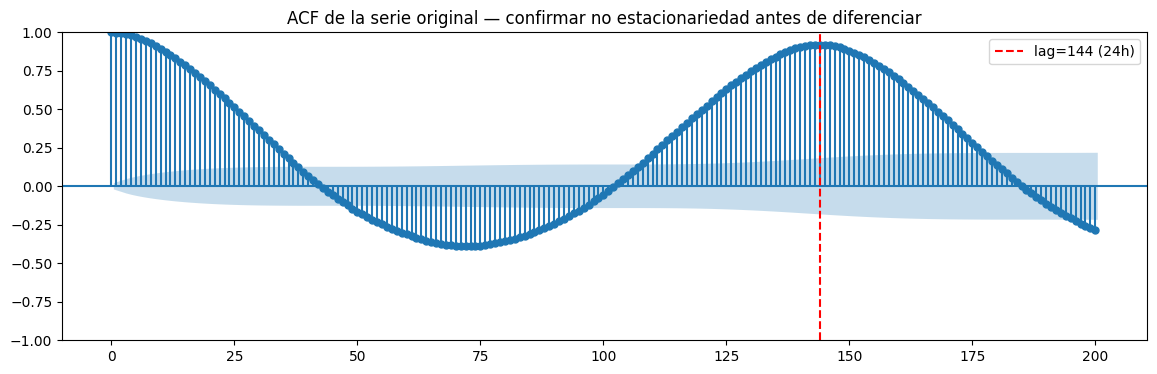

In [18]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(milan["internet"].dropna(), lags=200, ax=ax)
plt.axvline(144, color="red", linestyle="--", label="lag=144 (24h)")
plt.title("ACF de la serie original — confirmar no estacionariedad antes de diferenciar")
plt.legend()
plt.show()